In [1]:
import ibis
from ibis import _, selectors as s
from utils.f_0_dirs import get_data_dirs
dirs = get_data_dirs("descriptives")
con = ibis.duckdb.connect(dirs.db_path, read_only=True)

# 2. Spatial distance $d_1$

In [3]:
# Number of peers per firm
# Group by firm_i and count the number of peers (firm_j) for each firm_i
# Group by firm_j and count the number of peers (firm_i) for each firm_j
# Sum then together for each firm to get total number of peers
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

t_distances = con.table("working_distance_ttwa_km")

t_peer_counts_i = (
    t_distances
    .select("firm_i")
    .group_by("firm_i")
    .aggregate(num_peers_i=_.count())
)
df_peer_counts_i = t_peer_counts_i.execute()
df_distances = (
    t_distances
    .select('distance_meters')
    .sample(0.01)
    .execute()
)
# Above threshold
threshold = 5000
above_t = (
    t_peer_counts_i
    .filter(_.num_peers_i > threshold)
    .count()
    .execute()
)
print(f"Number of firms with more than {threshold:,} peers: {above_t:,}")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Bitstream Vera Serif', 'Computer Modern Roman']

plt.figure(figsize=(12, 6))
plt.hist(
    df_peer_counts_i['num_peers_i'],
    bins=range(0, threshold, 50),
    alpha=0.7,
    color='blue',
    edgecolor='black'
)
plt.xlabel("Number of Peers")
plt.ylabel("Number of Firms")
plt.grid(True, which="both", ls="--", linewidth=0.5)
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

n_dist = df_distances.shape[0]
print(f"Plotting sample of distance: 1% sample ({n_dist:,})")
plt.figure(figsize=(12, 6))
plt.hist(
    df_distances['distance_meters'],
    weights=np.ones(n_dist),
    bins=range(0, 10000, 100),
    alpha=0.7,
    color='blue',
    edgecolor='black'
)
plt.xlabel("Distance (meters)")
plt.ylabel("Number of Firms")
plt.grid(True, which="both", ls="--", linewidth=0.5)
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

# Summary statistics
df_counts_summ = (
    t_peer_counts_i
    .select('num_peers_i')
    .aggregate(
        count=_.count(),
        mean=_['num_peers_i'].mean(),
        median=_['num_peers_i'].median(),
        std=_['num_peers_i'].std(),
        min=_['num_peers_i'].min(),
        max=_['num_peers_i'].max()
    )
    .execute()
)
print(
    t_distances
    .select('distance_meters')
    .sample(0.01)
    .describe()
    .execute()
)
df_distances_summ = (
    t_distances
    .select('distance_meters')
    .sample(0.01)
    .aggregate(
        count=_.count(),
        mean=_['distance_meters'].mean(),
        median=_['distance_meters'].median(),
        std=_['distance_meters'].std(),
        min=_['distance_meters'].min(),
        max=_['distance_meters'].max()
    )
    .execute()
)
# Join these two tables. They each have 1 row and 6 columns
# So have them be 2 rows with the same columns
# And add an index/first column label describing each
df_combined = (
    df_counts_summ
    .assign(stat_type='num_peers_i')
    .append(df_distances_summ.assign(stat_type='distance_km'))
    .set_index('stat_type')
)
display(df_combined)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

IOException: IO Error: Could not read from file "/mnt/c/Users/lazym/Documents/Code/dissertation/build/output/fame_data.duckdb": Cannot allocate memory

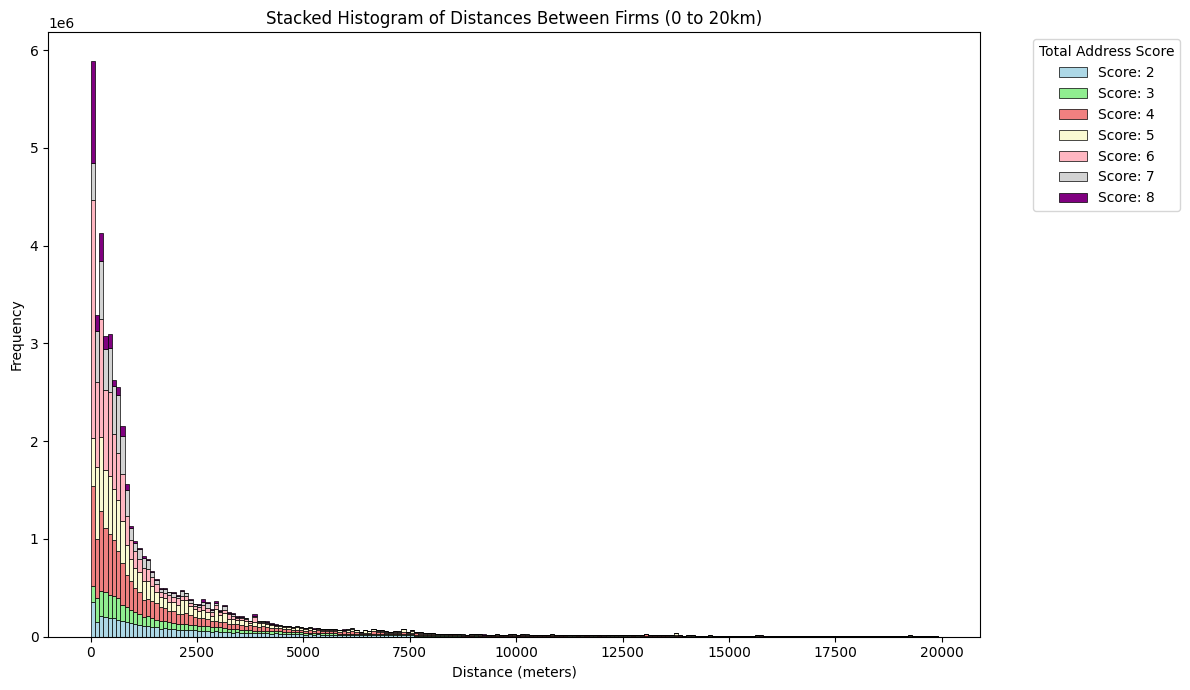

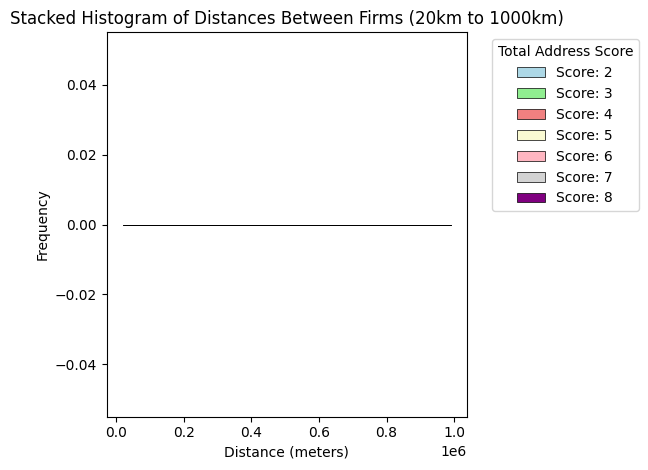

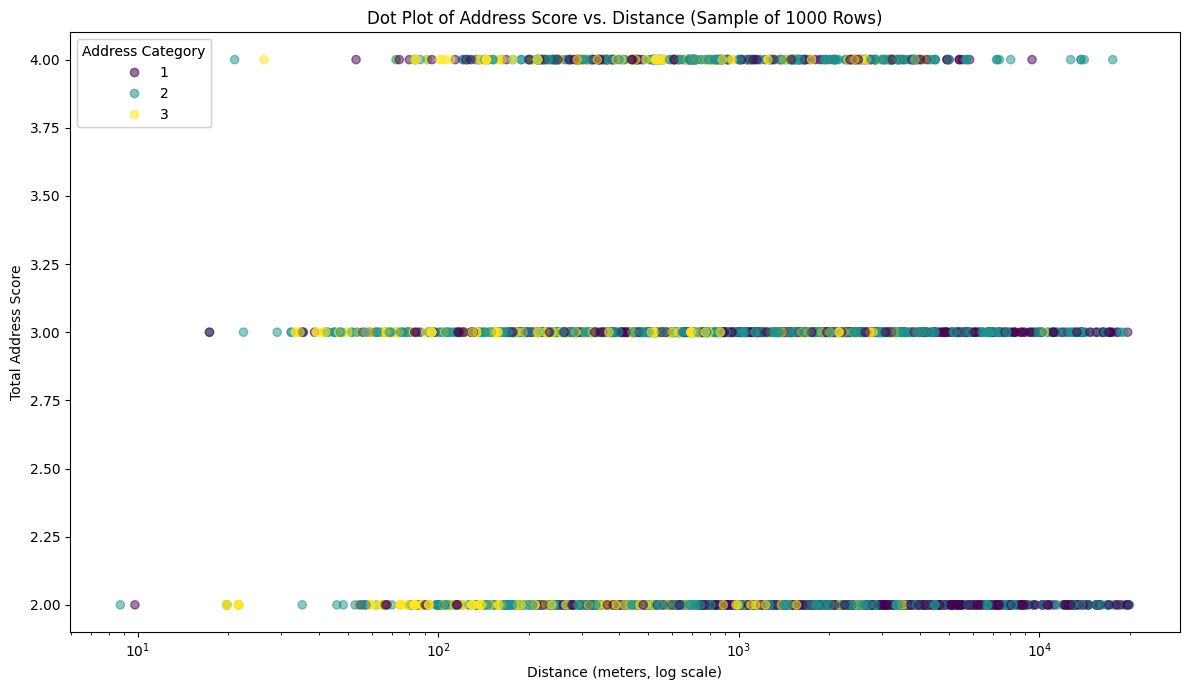

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from ibis import _

cut_off = 20000

# 1. Execute the query and return the FULL DataFrame (both columns)
table_distances = (
    table_joined
    .select(["distance_meters", "address_lvl_i", "address_case_i", "address_lvl_j", "address_case_j"])
    .mutate(
        # Note: Casting the boolean to an integer ensures the multiplication works safely across SQL backends
        address_score_i = _.address_lvl_i + (_.address_case_i == 'ro').cast('int8') * 2,
        address_score_j = _.address_lvl_j + (_.address_case_j == 'ro').cast('int8') * 2,
    )
    .mutate(
        address_score_total = _.address_score_i + _.address_score_j
    )
    .filter(_.address_score_total.notnull())
)
df_distances = (
    table_distances
    .select(["distance_meters", "address_score_total"])
    .execute()
)

# 2. Group the distances by their total score into a list of arrays
# Matplotlib requires the shape: [array(score_1_distances), array(score_2_distances), ...]
unique_scores = sorted(df_distances['address_score_total'].unique())
data_to_plot = [
    df_distances[df_distances['address_score_total'] == score]['distance_meters'].values 
    for score in unique_scores
]

# Create labels mapping to each array for the legend
labels = [f"Score: {int(score)}" for score in unique_scores]

color_map = [
    'lightblue', 'lightgreen', 'lightcoral', 'lightgoldenrodyellow', 'lightpink', 'lightgray',
    'purple', 'orange', 'cyan', 'magenta', 'yellow', 'brown', 'teal', 'navy', 'olive'
]

# 3. Plot the stacked histogram
plt.figure(figsize=(12, 7))

# Pass the list of arrays, set stacked=True
plt.hist(
    data_to_plot, 
    bins=np.arange(0, cut_off, 100), 
    stacked=True, 
    color=color_map[:len(unique_scores)], 
    label=labels,
    edgecolor='black',
    linewidth=0.5
)
plt.title(f'Stacked Histogram of Distances Between Firms (0 to {cut_off/1000:.0f}km)')
plt.xlabel('Distance (meters)')
plt.ylabel('Frequency')
plt.legend(title='Total Address Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ensures the external legend isn't cut off
plt.show()

# Pass the list of arrays, set stacked=True
plt.hist(
    data_to_plot, 
    bins=np.arange(cut_off, 1000000, 10000), 
    stacked=True, 
    color=color_map[:len(unique_scores)], 
    label=labels,
    edgecolor='black',
    linewidth=0.5
)
plt.title(f'Stacked Histogram of Distances Between Firms ({cut_off/1000:.0f}km to 1000km)')
plt.xlabel('Distance (meters)')
plt.ylabel('Frequency')
plt.legend(title='Total Address Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ensures the external legend isn't cut off
plt.show()

# Take a sample of 1000 rows
# Plot a dot plot with address_score on the y-axis and distance_meters on the x-axis.
# Use a log scale for the x-axis to better visualize the distribution of distances.
# Sample unique_scores for 1000 rows
# address_category is 1 if both are 'pta', 2 if one is 'pta' and the other is 'ro', and 3 if both are 'ro'
df_sample = (
    table_distances
    .mutate(
        address_score = table_distances.address_lvl_i + table_distances.address_lvl_j,
        address_cat=ibis.cases(
            ((table_distances.address_case_i == 'pta') & (table_distances.address_case_j == 'pta'), 1),
            ((table_distances.address_case_i == 'ro') & (table_distances.address_case_j == 'ro'), 3),
            else_=2
        )
    )
    .sample(0.0001)
    .execute()
)
# Plot a dot plot with address_score on the y-axis and distance_meters on the x-axis.
# Use address_cat to denote series
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    df_sample['distance_meters'], 
    df_sample['address_score'], 
    c=df_sample['address_cat'], 
    cmap='viridis', 
    alpha=0.5
)
plt.xscale('log')
plt.title('Dot Plot of Address Score vs. Distance (Sample of 1000 Rows)')
plt.xlabel('Distance (meters, log scale)')
plt.ylabel('Total Address Score')
legend1 = plt.legend(*scatter.legend_elements(), title="Address Category")
plt.gca().add_artist(legend1)
plt.tight_layout()
plt.show()
